# Kernel PCA: Nonlinear Dimensionality Reduction

## Overview

**Principal Component Analysis (PCA)** finds a linear subspace that captures maximum variance.
It fails when the data lives on a nonlinear manifold.
**Kernel PCA** (KPCA), introduced by Schölkopf, Smola, and Müller (1998), extends PCA
to nonlinear feature spaces via the **kernel trick**:
instead of explicitly mapping data into a high-dimensional feature space $\mathcal{H}$,
we work with the $n \times n$ kernel matrix $K$ whose entries are inner products
$K_{ij} = \langle \phi(x_i), \phi(x_j)\rangle_{\mathcal{H}}$.

### Why Kernel PCA Matters

- It reveals **nonlinear structure** that linear PCA cannot capture.
- It requires no explicit knowledge of the feature map $\phi$: only the kernel $K$ is needed.
- It is a foundation for **kernel Fisher discriminant**, **spectral clustering**,
  and **manifold learning** methods (Isomap, LLE, Laplacian Eigenmaps).

### What This Notebook Demonstrates

1. Linear PCA fails to separate the two-moons dataset.
2. Kernel PCA (Gaussian kernel) successfully separates the two moons.
3. Effect of the bandwidth $\sigma$ on the projection quality.
4. Out-of-sample extension for new points.
5. Comparison of kernel PCA components for different $\sigma$ values.

### Linear PCA

Given centered data matrix $X \in \mathbb{R}^{n \times d}$ (rows are data points),
linear PCA finds the eigenvectors of the covariance matrix

$$
C = \frac{1}{n} X^T X \in \mathbb{R}^{d \times d}.
$$

The projection onto the first $q$ components is $Z = X V_q$ where $V_q$ has
the top $q$ eigenvectors as columns.

### Kernel PCA

**Step 1**: Compute the kernel matrix $K \in \mathbb{R}^{n \times n}$:

$$
K_{ij} = k(x_i, x_j) = \exp\!\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right).
$$

**Step 2**: Center $K$ in feature space:

$$
\tilde{K} = J K J, \qquad J = I_n - \frac{1}{n}\mathbf{1}\mathbf{1}^T.
$$

This is equivalent to centering $\phi(x_i)$ in $\mathcal{H}$.

**Step 3**: Compute the eigendecomposition $\tilde{K} = U \Lambda U^T$.
The kernel PCA projections are the columns of

$$
Z = U_q \Lambda_q^{1/2} \in \mathbb{R}^{n \times q},
$$

where $U_q, \Lambda_q$ contain the top $q$ eigenpairs.

### Out-of-Sample Extension

For a new point $x^*$, compute $k^* \in \mathbb{R}^n$ with $k^*_i = k(x^*, x_i)$,
then center it:

$$
\tilde{k}^* = k^* - \frac{1}{n}K\mathbf{1} - \frac{1}{n}\mathbf{1}\overline{k}^* + \frac{1}{n^2}\mathbf{1}^T K \mathbf{1}
$$

and project: $z^* = U_q^T \tilde{k}^* \odot \lambda_q^{-1/2}$.

### Setup and Data

We use the classic **two-moons** dataset: two interleaved half-circles in $\mathbb{R}^2$.
The classes are not linearly separable.
We implement kernel PCA from scratch using NumPy eigendecomposition.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(5)

def make_two_moons(n_per_class=150, noise=0.08, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    t = np.linspace(0, np.pi, n_per_class)
    X0 = np.column_stack([np.cos(t), np.sin(t)])
    X1 = np.column_stack([1 - np.cos(t), 0.5 - np.sin(t)])
    X = np.vstack([X0, X1]) + rng.normal(0, noise, (2*n_per_class, 2))
    y = np.array([0]*n_per_class + [1]*n_per_class)
    return X, y

n_per = 150
X, y = make_two_moons(n_per_class=n_per, noise=0.1, rng=rng)
colors = np.where(y == 0, '#1f77b4', '#d62728')

print(f'Data shape: {X.shape}, classes: {np.unique(y)}')

Data shape: (300, 2), classes: [0 1]


### Linear PCA: Failure on Two Moons

Linear PCA computes the eigenvectors of the centered covariance matrix $X_c^T X_c / n$.
The first principal component $z_1 = X_c v_1$ captures maximum variance but
cannot separate the two moons: the classes overlap completely in the PCA projection.

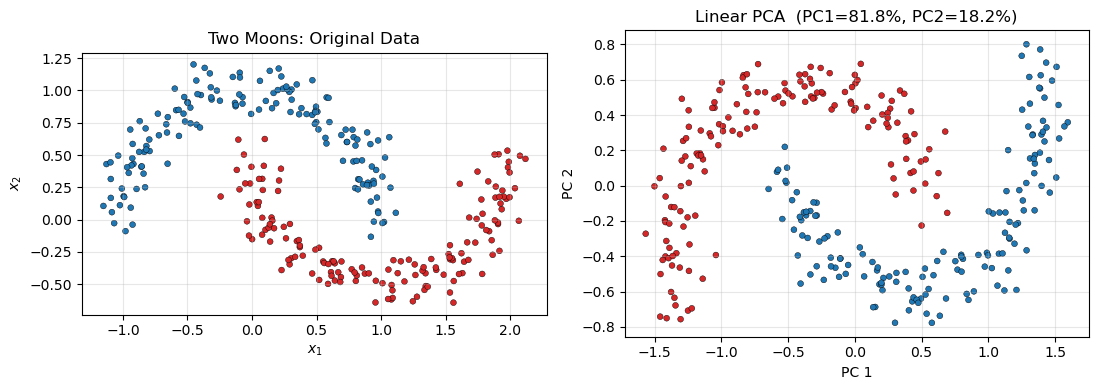

Linear PCA cannot separate the two classes.


In [2]:
def linear_pca(X, n_components=2):
    """Standard linear PCA. Returns projected data and explained variance ratio."""
    X_c = X - X.mean(axis=0)
    C = X_c.T @ X_c / len(X)
    eigenvalues, eigenvectors = np.linalg.eigh(C)
    # Sort descending
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    Z = X_c @ eigenvectors[:, :n_components]
    evr = eigenvalues[:n_components] / eigenvalues.sum()
    return Z, evr

Z_lin, evr_lin = linear_pca(X, n_components=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', lw=0.3, s=18)
axes[0].set_title('Two Moons: Original Data')
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$')
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(Z_lin[:, 0], Z_lin[:, 1], c=colors, edgecolors='k', lw=0.3, s=18)
axes[1].set_title(f'Linear PCA  (PC1={evr_lin[0]:.1%}, PC2={evr_lin[1]:.1%})')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linear_pca_moons.png', dpi=90, bbox_inches='tight')
plt.show()
print('Linear PCA cannot separate the two classes.')

### Kernel PCA Implementation

We implement KPCA in three steps:
1. Build the Gaussian kernel matrix $K_{ij} = \exp(-\|x_i - x_j\|^2 / 2\sigma^2)$.
2. Center: $\tilde{K} = JKJ$.
3. Eigendecompose $\tilde{K}$ and extract top components.

The centering matrix $J = I - \frac{1}{n}\mathbf{1}\mathbf{1}^T$ ensures the feature-space
representations are zero-mean, as required by PCA.

In [3]:
def rbf_kernel(X1, X2, sigma):
    """Gaussian RBF kernel matrix."""
    sq_dists = (np.sum(X1**2, axis=1)[:, None]
                + np.sum(X2**2, axis=1)[None, :]
                - 2 * X1 @ X2.T)
    sq_dists = np.maximum(sq_dists, 0)  # numerical safety
    return np.exp(-sq_dists / (2 * sigma**2))

def center_kernel(K):
    """Center kernel matrix in feature space: K_tilde = J K J."""
    n = K.shape[0]
    one_n = np.ones((n, n)) / n
    return K - one_n @ K - K @ one_n + one_n @ K @ one_n

def kernel_pca(X, sigma, n_components=2):
    """Kernel PCA. Returns projections and stored quantities for out-of-sample."""
    n = len(X)
    K = rbf_kernel(X, X, sigma)
    K_tilde = center_kernel(K)

    eigenvalues, eigenvectors = np.linalg.eigh(K_tilde)
    # Sort descending, keep positive
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Keep only positive eigenvalues
    pos = eigenvalues > 1e-10
    eigenvalues  = eigenvalues[pos]
    eigenvectors = eigenvectors[:, pos]

    nc = min(n_components, len(eigenvalues))
    Z = eigenvectors[:, :nc] * np.sqrt(eigenvalues[:nc])

    return Z, eigenvalues, eigenvectors, K

sigma_demo = 0.4
Z_kpca, evals, evecs, K_train = kernel_pca(X, sigma=sigma_demo, n_components=2)

evr_kpca = evals[:2] / evals.sum()
print(f'Kernel PCA (sigma={sigma_demo}): PC1={evr_kpca[0]:.1%}, PC2={evr_kpca[1]:.1%}')

Kernel PCA (sigma=0.4): PC1=17.5%, PC2=14.6%


### Visual Comparison: Linear PCA vs. Kernel PCA

The first component of kernel PCA with an appropriate $\sigma$ cleanly separates
the two moons along a single axis, while linear PCA leaves them entangled.

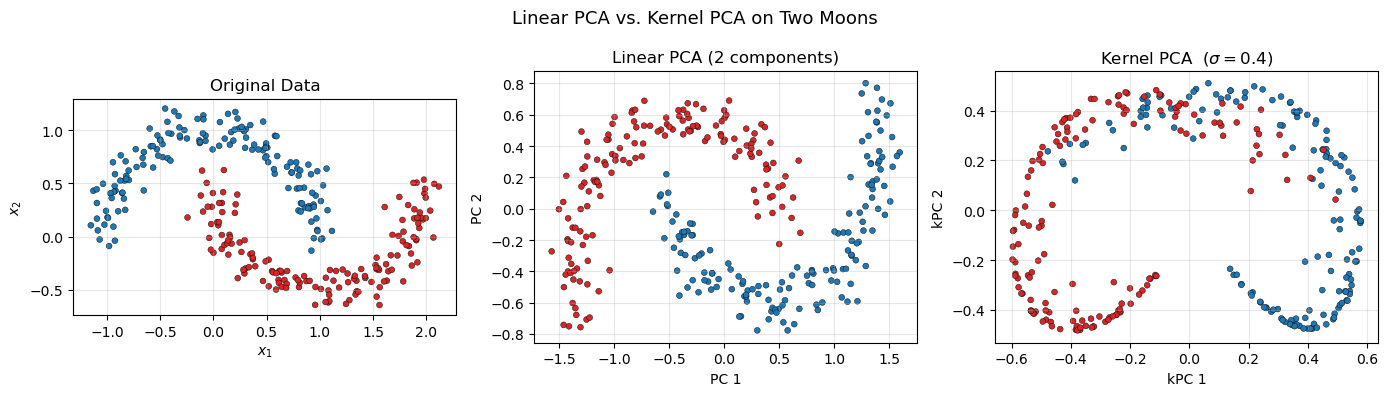

In [4]:
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))

# Original data
axes2[0].scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', lw=0.3, s=18)
axes2[0].set_title('Original Data')
axes2[0].set_xlabel('$x_1$'); axes2[0].set_ylabel('$x_2$')
axes2[0].set_aspect('equal'); axes2[0].grid(True, alpha=0.3)

# Linear PCA (first 2 components)
axes2[1].scatter(Z_lin[:, 0], Z_lin[:, 1], c=colors, edgecolors='k', lw=0.3, s=18)
axes2[1].set_title('Linear PCA (2 components)')
axes2[1].set_xlabel('PC 1'); axes2[1].set_ylabel('PC 2')
axes2[1].grid(True, alpha=0.3)

# Kernel PCA
axes2[2].scatter(Z_kpca[:, 0], Z_kpca[:, 1], c=colors, edgecolors='k', lw=0.3, s=18)
axes2[2].set_title(f'Kernel PCA  ($\\sigma={sigma_demo}$)')
axes2[2].set_xlabel('kPC 1'); axes2[2].set_ylabel('kPC 2')
axes2[2].grid(True, alpha=0.3)

plt.suptitle('Linear PCA vs. Kernel PCA on Two Moons', fontsize=13)
plt.tight_layout()
plt.savefig('kpca_comparison.png', dpi=90, bbox_inches='tight')
plt.show()

### Effect of Bandwidth $\sigma$

The bandwidth $\sigma$ controls the scale at which two points are considered
"similar" in feature space.

- **Small $\sigma$**: the kernel becomes nearly diagonal ($K \approx I$),
  and the kernel PCA projection becomes uninformative.
- **Large $\sigma$**: the kernel approaches the constant-1 matrix,
  and all points appear similar — again losing discriminative power.
- **Intermediate $\sigma$**: captures the manifold structure.

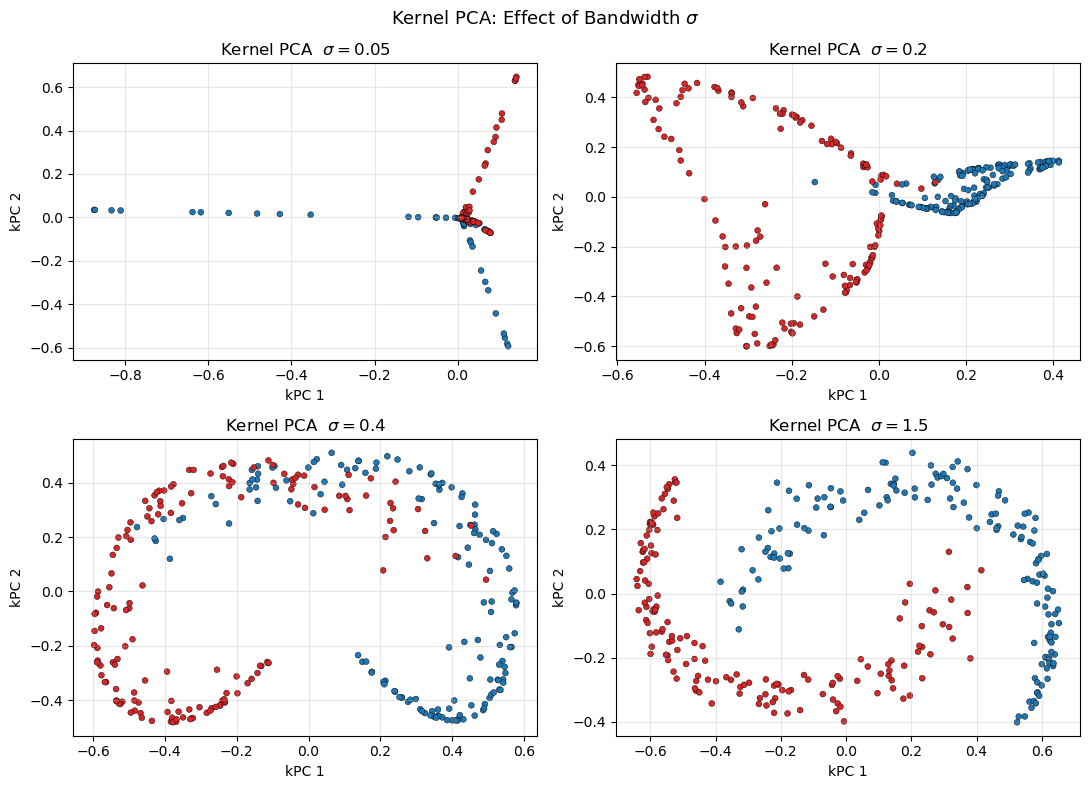

In [5]:
sigmas = [0.05, 0.2, 0.4, 1.5]

fig3, axes3 = plt.subplots(2, 2, figsize=(11, 8))
axes3 = axes3.ravel()

for ax, sig in zip(axes3, sigmas):
    Z, ev, _, _ = kernel_pca(X, sigma=sig, n_components=2)
    ax.scatter(Z[:, 0], Z[:, 1], c=colors, edgecolors='k', lw=0.3, s=18)
    ax.set_title(f'Kernel PCA  $\\sigma = {sig}$')
    ax.set_xlabel('kPC 1'); ax.set_ylabel('kPC 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Kernel PCA: Effect of Bandwidth $\\sigma$', fontsize=13)
plt.tight_layout()
plt.savefig('kpca_sigma.png', dpi=90, bbox_inches='tight')
plt.show()

### Out-of-Sample Extension

Kernel PCA does not directly provide an encoding for new points not seen during training.
The **Nyström out-of-sample extension** projects a new point $x^*$ by:

$$
z^* = \tilde{k}^{*T} U_q \Lambda_q^{-1/2},
$$

where $\tilde{k}^*$ is the centered kernel vector between $x^*$ and all training points.
We verify this on a held-out test set from the same distribution.

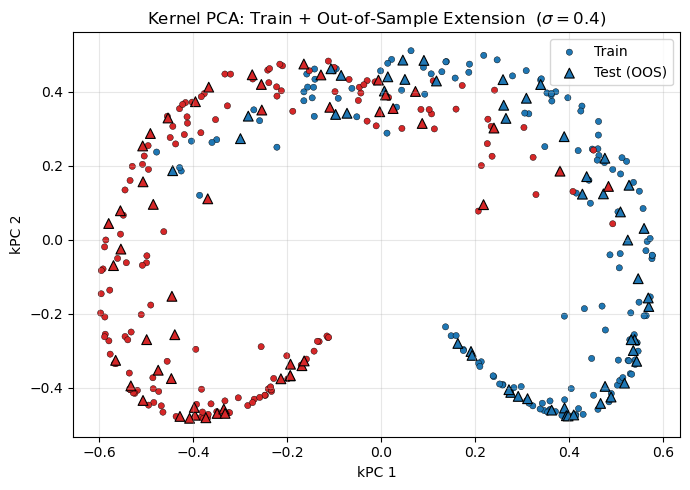

In [6]:
def kpca_transform_new(X_train, X_new, sigma, eigenvectors, eigenvalues, K_train, n_components=2):
    """Project new points into the kernel PCA space (out-of-sample extension)."""
    n = len(X_train)
    K_new = rbf_kernel(X_new, X_train, sigma)  # (n_new, n)

    # Center the new kernel vectors
    K_row_mean = K_train.mean(axis=1)    # mean of each row of K_train
    K_total_mean = K_train.mean()         # overall mean
    K_new_centered = (K_new
                      - K_new.mean(axis=1, keepdims=True)
                      - K_row_mean[None, :]
                      + K_total_mean)

    nc = min(n_components, len(eigenvalues))
    return K_new_centered @ eigenvectors[:, :nc] / np.sqrt(eigenvalues[:nc])

# Generate a test set
X_test_new, y_test_new = make_two_moons(n_per_class=50, noise=0.1,
                                          rng=np.random.default_rng(99))
colors_test = np.where(y_test_new == 0, '#1f77b4', '#d62728')

Z_train_kpca, evals_oos, evecs_oos, K_tr_oos = kernel_pca(X, sigma=sigma_demo, n_components=2)
Z_test_kpca = kpca_transform_new(X, X_test_new, sigma_demo,
                                   evecs_oos, evals_oos, K_tr_oos, n_components=2)

fig4, ax4 = plt.subplots(figsize=(7, 5))
colors_tr = np.where(y == 0, '#1f77b4', '#d62728')
ax4.scatter(Z_train_kpca[:, 0], Z_train_kpca[:, 1],
            c=colors_tr, edgecolors='k', lw=0.3, s=20, label='Train', marker='o')
ax4.scatter(Z_test_kpca[:, 0], Z_test_kpca[:, 1],
            c=colors_test, edgecolors='k', lw=0.8, s=50, label='Test (OOS)', marker='^')
ax4.set_title(f'Kernel PCA: Train + Out-of-Sample Extension  ($\\sigma={sigma_demo}$)')
ax4.set_xlabel('kPC 1'); ax4.set_ylabel('kPC 2')
ax4.legend(); ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kpca_oos.png', dpi=90, bbox_inches='tight')
plt.show()

### Static Snapshot

Generates `snippet.png` for the repository gallery — a compact three-panel view
showing original data, linear PCA failure, and kernel PCA success.

In [7]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    import numpy as _np

    _rng = _np.random.default_rng(5)
    _npc = 120

    def _moons(n, noise, rng):
        t = _np.linspace(0, _np.pi, n)
        X0 = _np.column_stack([_np.cos(t), _np.sin(t)])
        X1 = _np.column_stack([1-_np.cos(t), .5-_np.sin(t)])
        Xout = _np.vstack([X0, X1]) + rng.normal(0, noise, (2*n, 2))
        return Xout, _np.array([0]*n+[1]*n)

    _X, _y = _moons(_npc, 0.1, _rng)
    _col = _np.where(_y==0,'#1f77b4','#d62728')

    def _rbf(X1, X2, s):
        d = _np.sum(X1**2,1)[:,None] + _np.sum(X2**2,1)[None,:] - 2*X1@X2.T
        return _np.exp(-_np.maximum(d,0)/(2*s**2))

    def _kpca(X, s, nc=2):
        K = _rbf(X, X, s)
        n = len(X); on = _np.ones((n,n))/n
        Kt = K - on@K - K@on + on@K@on
        ev, evec = _np.linalg.eigh(Kt)
        idx = _np.argsort(ev)[::-1]; ev=ev[idx]; evec=evec[:,idx]
        pos = ev > 1e-10; ev=ev[pos]; evec=evec[:,pos]
        return evec[:,:nc]*_np.sqrt(ev[:nc])

    def _lpca(X):
        Xc = X - X.mean(0)
        ev, evec = _np.linalg.eigh(Xc.T@Xc/len(X))
        return Xc @ evec[:, ::-1][:, :2]

    _Zl = _lpca(_X)
    _Zk = _kpca(_X, 0.4)

    _fig, _axes = _plt.subplots(1, 3, figsize=(10, 3.5))
    _axes[0].scatter(_X[:,0], _X[:,1], c=_col, edgecolors='k', lw=.3, s=14)
    _axes[0].set_title('Original', fontsize=10); _axes[0].set_aspect('equal')
    _axes[0].grid(True, alpha=.3); _axes[0].set_xticks([]); _axes[0].set_yticks([])

    _axes[1].scatter(_Zl[:,0], _Zl[:,1], c=_col, edgecolors='k', lw=.3, s=14)
    _axes[1].set_title('Linear PCA', fontsize=10)
    _axes[1].grid(True, alpha=.3); _axes[1].set_xticks([]); _axes[1].set_yticks([])

    _axes[2].scatter(_Zk[:,0], _Zk[:,1], c=_col, edgecolors='k', lw=.3, s=14)
    _axes[2].set_title('Kernel PCA', fontsize=10)
    _axes[2].grid(True, alpha=.3); _axes[2].set_xticks([]); _axes[2].set_yticks([])

    _fig.suptitle('Kernel PCA on Two Moons', fontsize=11)
    _plt.tight_layout()
    _plt.savefig('snippet.png', dpi=100, bbox_inches='tight')
    _plt.close(_fig)
    print('snippet.png saved.')

snippet.png saved.


### Interactive: Explore Bandwidth and Number of Components

Use the sliders to change $\sigma$ and the component pair to display.
Observe which bandwidth reveals the manifold structure most clearly,
and how higher components capture finer details.

## Takeaways

- **Linear PCA** is limited to linear subspaces. It cannot separate classes
  whose separating boundary is nonlinear (as in the two-moons case).
- **Kernel PCA** implicitly maps data into a high-dimensional feature space
  and performs linear PCA there, revealing nonlinear structure through the
  centered kernel matrix $\tilde{K}$.
- The **centering step** is essential: without it, the feature-space mean is nonzero
  and the eigenvectors do not correspond to principal directions.
- The bandwidth $\sigma$ determines the geometric scale of the nonlinear structure captured:
  too small → no global structure; too large → collapses to linear PCA.
- **Out-of-sample extension** via the Nyström formula allows encoding new points
  without recomputing the full eigendecomposition.
- Kernel PCA scales as $\mathcal{O}(n^3)$; for large $n$, **sparse approximations** or
  **Nyström low-rank approximations** are used.

## Bibliography

- B. Schölkopf, A. Smola, K.-R. Müller, *Nonlinear Component Analysis as a Kernel
  Eigenvalue Problem*, Neural Computation, 1998.
- B. Schölkopf and A. Smola, *Learning with Kernels*, MIT Press, 2002.
  Chapter 14: Kernel PCA.
- C. Williams and M. Seeger, *Using the Nyström Method to Speed Up Kernel Machines*,
  NeurIPS, 2001.
- J. Ham, D. Lee, S. Mika, B. Schölkopf, *A Kernel View of the Dimensionality
  Reduction of Manifolds*, ICML, 2004.